In [2]:
"Up and running"

'Up and running'

In [11]:
# Built-in modules
import re

# Third-party modules
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Custom modules
from misc import paths
from misc import style

In [5]:
# Read the uniprot_nr.txt file
df = pd.read_csv(
    paths.INTACT / '2026-01-09' / 'uniprot_nr.txt', 
    sep='\t'
)

In [9]:
def extract_intact_miscore(string: str) -> float:
    """
    Extracts the intact-miscore value from a given string.

    Parameters
    ----------
    string : str
        The input string from which to extract the intact-miscore value.

    Returns
    -------
    float
        The extracted intact-miscore value as a float. If the value is not 
        found, returns np.nan.
    """
    match = re.search(r'intact-miscore:([0-9.]+)', string)
    return float(match.group(1)) if match else np.nan

mi_scores = df['Confidence value(s)'].apply(extract_intact_miscore)
mi_scores

0          0.67
1          0.44
2          0.82
3          0.44
4          0.35
           ... 
1075911    0.37
1075912    0.37
1075913    0.37
1075914    0.37
1075915    0.37
Name: Confidence value(s), Length: 1075916, dtype: float64

Text(0, 0.5, 'Frequency')

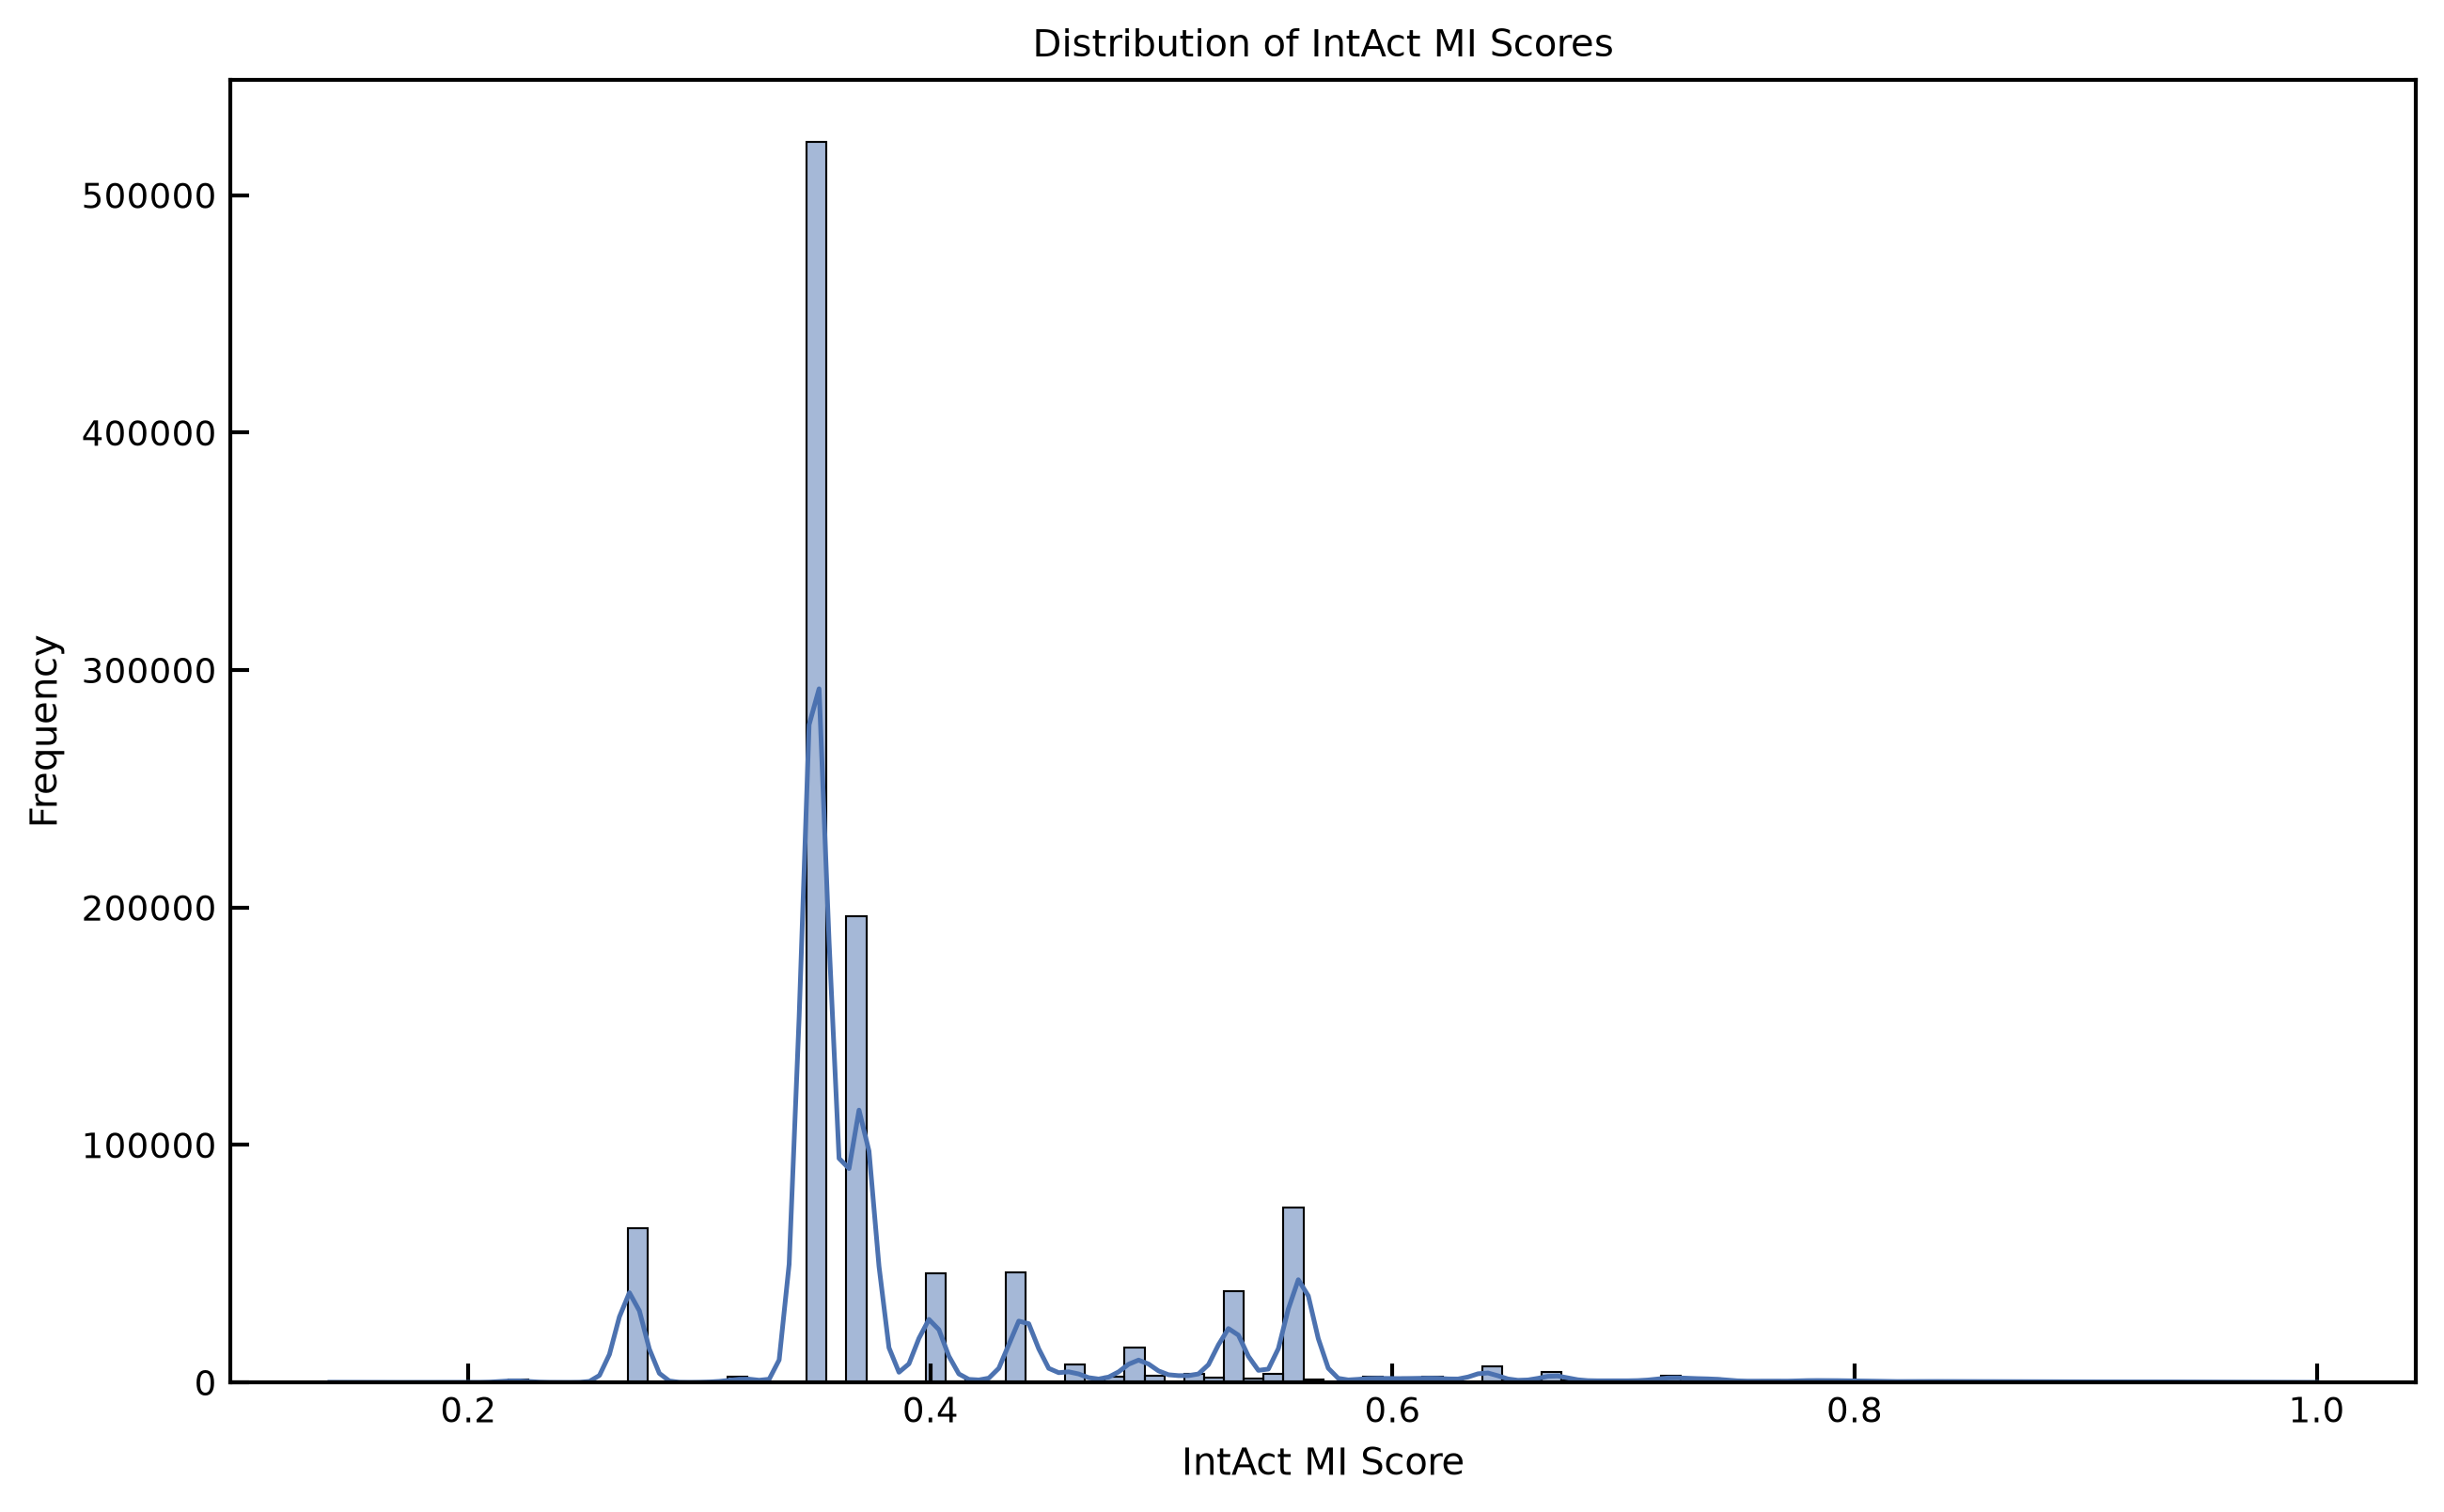

In [14]:
plt.figure(figsize=(10, 6))
sns.histplot(mi_scores, bins=100, kde=True)
plt.title('Distribution of IntAct MI Scores')
plt.xlabel('IntAct MI Score')
plt.ylabel('Frequency')